## COE Final Project Part 2 - Group (Conner Jaquess, Wilson Serrano
# Section 1: Stiff Scalar ODE Selection
We chose the Mechanical System with High Damping, which is a over damped spring-mass system. This can be seen in applications like shock absorbers or vibration dampers. The governing ODE is modeled by the equation, 

$$dy/dt = -5000y + 0.002sin(t)$$

with $ dy/dt = f(t, y) $. This function is made up of a few main components. First,  $ \lambda = 5000 $ represents the high dampening rate. Second, $ g(t) = 0.002sin(t) $ represents a slow external force in terms of a function. We are also given an initial displacement of 1 meter at $ t = 0 $. This is an important system because it gives us the ability to measure these dampers or absorbers without needing millions of data points, rather just a computer with the ability to model this function. Without it, many engineering applications like car suspensions, bridges, or aircraft dampers would not be able to be modeled before testing, which could be costly or dangerous to users.

# Section 2: Demonstration of Stiffness
We are going to use Euler's Forward Method to see the limitations of these different methods when proving stiffness. We will be using a fast time scale and a slow time scale to see how stiffness behaves between these two time scales quantitatively. Our fast time scale is our $ \lambda = 5000 $. Our slow time scale would be the external force of $ g(t) = 0.002sin(t) $ which completes 1 oscillation every 6.28 seconds. This is important because with our damping parameter of 0.0002 seconds and our slow time scale of 6.28 seconds, we  achieve internal equilibrium at 0.2 milliseconds. Additionally, we can expect our Forward Euler's equation to be limited by our fast time scale. To remain stable, our step size, $ h $, is limited by the equation $ h < 2 / 5000 = 0.0004 seconds $.

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# This is the ODE for the mechanical system with high damping.
# y is displacement and t is time.
def f(t, y):
    return -5000*y + 0.002*np.sin(t)


def forwardEuler(t_start, t_end, y_0, h):
    
    # Create time values and an empty array for y values
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    
    # Initial condition
    y_values[0] = y_0
    
    # Euler Forward loop
    for i in range(1, len(t_values)):
        t_n = t_values[i - 1]
        y_n = y_values[i - 1]
        
        y_values[i] = y_n + h*f(t_n, y_n)
    
    return t_values, y_values

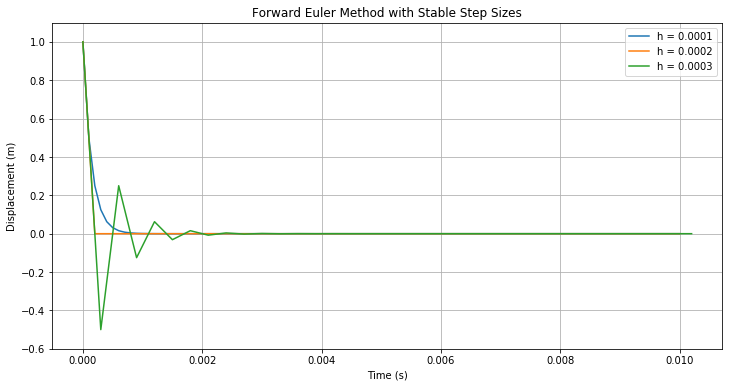

In [71]:
# Stable step sizes for Forward Euler
h_values = [0.0001, 0.0002, 0.0003]

plt.figure(figsize=(12, 6))

for h in h_values:
    t, y = forwardEuler(0, .01, 1, h)
    plt.plot(t, y, label=f"h = {h}")

plt.ylim(-0.6, 1.1)
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("Forward Euler Method with Stable Step Sizes")
plt.legend()
plt.grid(True)
plt.show()

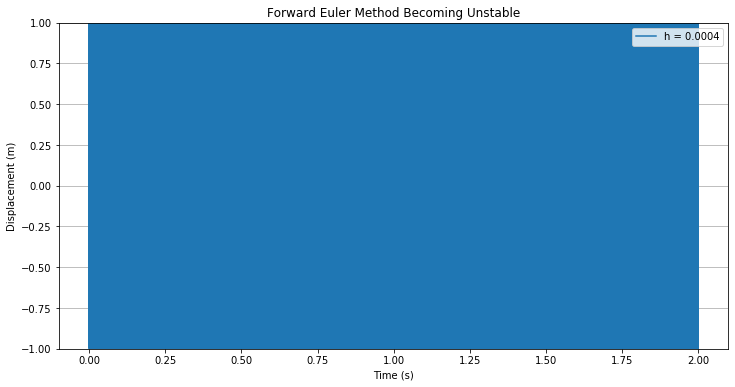

In [78]:
# This step size should be unstable because Forward Euler needs h < 2/lambda.
# Since lambda = 5000, h must be less than 0.0004.
h_values = [0.0004]

plt.figure(figsize=(12, 6))

for h in h_values:
    t, y = forwardEuler(0, 2, 1, h)
    plt.plot(t, y, label=f"h = {h}")

plt.ylim(-1, 1)
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("Forward Euler Method Becoming Unstable")
plt.legend()
plt.grid(True)
plt.show()

As we can observe, the step size of $ h = .0003 $ is stable and gives us a good idea of how we acheive stability. However, there is still some overshooting that occurs as it tries to reach equilibrium. We can also observe that the step size of $ h = 0.0004 $ is very unstable shows a plot which shows no trends or patterns other than dramatic oscillations. Because of how stiff this problem is, methods that are explicit, like Euler's, would be impractical because of two reasons: the amount of steps needed and low efficiency. To model just 2 seconds of motion, we would need 5,000 steps or data points. This is a large load and for most practical applications you would want to model at least a few seconds, which would be both time and resource consuming just to collect a few seconds of data. This can be blamed mainly on the lack of efficiency in methods like Euler's. These small steps that are needed to accurately model the sine wave are mainly due to the stability that is needed to model the sine wave and damping. If we used an implict method, we would be able to very easily keep stability and increase step size, preventing large data sets or unstability.

# Section 3: Mathematical Setup

To get rid of this stability limitations that we mentioned in the previous section, we will use Euler's Backward Method which is implicit. First, we need to set up our residual function. We will use the new implicit equation of $$y_{n+1} = y_n + h \cdot f(t_{n+1}, y_{n+1})$$ but after rearranging and plugging in our specific ODE, we end up with: $$g(y_{n+1}) = y_{n+1} - y_n - h(-5000y_{n+1} + 0.002\sin(t_{n+1}))$$. We will then will find our g' to use the Newton-Raphson method. When taking the derivative of the equation we just found, we get $$g'(y_{n+1}) = 1 - h(-5000) = 1 + 5000h$$ so that we can set up our equation. 

Now that we have both our residual and Analytical derivative equations, we can get the following Newton-Raphson equation: $$y_{n+1}^{k+1} = y_{n+1}^{k} - \frac{y_{n+1}^{k} - y_n - h(-5000y_{n+1}^{k} + 0.002\sin(t_{n+1}))}{1 + 5000h}$$

# Section 4: Implementation

The implementation portion below includes the governing ODE, analytical derivative of the residual, Newton-Raphson root finder, and the implicit Euler's Backward loop.

In [73]:
def f(t, y):
    return -5000*y + 0.002*np.sin(t)


def residual_prime(h):
    return 1 + 5000*h


def newton_raphson(y_n, t_next, h, tolerance, max_iterations=20):
    
    # Using the current y value as the first guess
    future_guess = y_n
    
    for iteration in range(max_iterations):
        
        # Residual equation from Backward Euler
        residual = future_guess - y_n - h*f(t_next, future_guess)
        
        # Check if the guess is already good enough
        if abs(residual) < tolerance:
            return future_guess, iteration
        
        # Newton-Raphson update
        future_guess = future_guess - residual/residual_prime(h)
    
    # If it does not converge, return the last guess
    return future_guess, max_iterations


# Backward Euler method
def backwardEuler(t_start, t_end, y_0, h, tolerance):
    
    # Create time values, y values, and iteration list
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    iterations_array = []
    
    # Initial condition
    y_values[0] = y_0
    
    # Backward Euler loop
    for i in range(1, len(t_values)):
        
        y_n = y_values[i - 1]
        t_next = t_values[i]
        
        # Solve for the next y value using Newton-Raphson
        y_values[i], iterations = newton_raphson(y_n, t_next, h, tolerance)

        iterations_array.append(iterations)
    
    return t_values, y_values, iterations_array

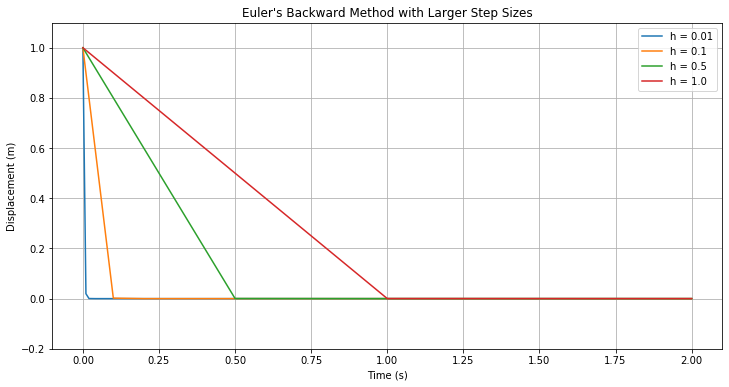

In [77]:
h_values = [0.01, 0.1, 0.5, 1.0]
all_iterations = []

plt.figure(figsize=(12, 6))

for h in h_values:
    t, y, iterations = backwardEuler(0, 2, 1, h, 0.000001)
    all_iterations.append(iterations)
    
    plt.plot(t, y, label=f"h = {h}")

plt.ylim(-0.2, 1.1)
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("Euler's Backward Method with Larger Step Sizes")
plt.legend()
plt.grid(True)
plt.show()

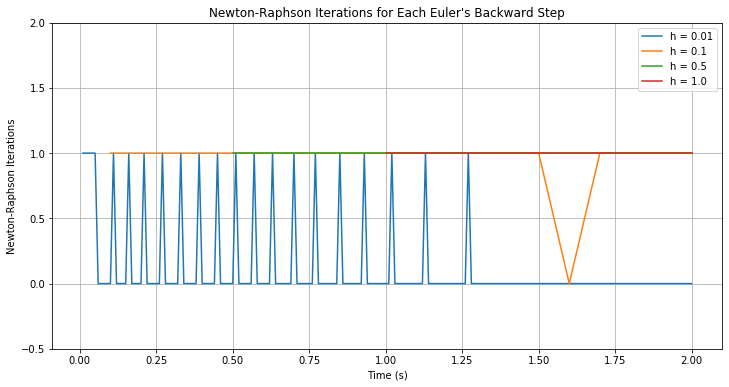

In [75]:
plt.figure(figsize=(12, 6))

for i in range(len(h_values)):
    h = h_values[i]
    
    t, y, iterations = backwardEuler(0, 2, 1, h, 0.000001)
    
    plt.plot(t[1:], iterations, label=f"h = {h}")

plt.ylim(-.5, 2)
plt.xlabel("Time (s)")
plt.ylabel("Newton-Raphson Iterations")
plt.title("Newton-Raphson Iterations for Each Euler's Backward Step")
plt.legend()
plt.grid(True)
plt.show()

In [76]:
# Average number of Newton-Raphson iterations for each h value
averages = []

for iterations in all_iterations:
    average_iterations = sum(iterations) / len(iterations)
    averages.append(average_iterations)

print("Average Newton-Raphson iterations for each h value:")
for i in range(len(h_values)):
    print(f"h = {h_values[i]}: {averages[i]}")

Average Newton-Raphson iterations for each h value:
h = 0.01: 0.135
h = 0.1: 0.975
h = 0.5: 1.0
h = 1.0: 1.0


# Section 5: Results and Analysis

The results before are the outcomes of using the step sizes of $ h = 0.01, 0.1, 0.5, $ and $ 1.0 $ seconds. As we can see in Euler's Backward Method Graph, they all reach a stable equilibrium at some point without diverging. However, we can see a loss of accuracy as the step sizes increase, with them taking longer to reach that equilibrium state. 

Despite this small amount of accuracy difference, we can definitivly see the difference in implicit and explicit methods. Where Euler's Forward failed at $ h = 0.0004 $, Euler's Backward stayed stable at $ h = 1.0 $. This gives us the option for an implicit method's step sizes incredibly larger than explicit methods, while still reaching a stable state. This implicit method gives engineers the ability to pick their desired step size without having to worry about the function giving an accurate depiction of the motion. Additionally, if the damping rate changes, it is no longer a determining factor in the stability of the data, rather just becomes another metric which they can manipulate freely. 

Because Euler's Backward Method needs a root-finding element, we needed to include Newton-Raphson Iterations to keep the tolerance within $1 \times 10^{-6}$. The ODE is linear so our residual function will also be linear. This will allow us to see the root of every iteration.

As we can see in the Newton-Raphson Iterations plot and the averages above, the larger step sizes of $ h = 0.5 $ and $ 1.0 $ averaged 1. This happens because the initial guess that happens there is outside of the tolerance defined above ( $1 \times 10^{-6}$ ). We can also observe the expected result of this number being lower in the smaller step sizes of $ h = 0.1 $ and $ 0.01 $. This happens because the iterations are within the tolerance and they leave the loop, which is clearly seen with the $ h = 0.01 $ line when it reaches 0, which is saying there were no iterations at that time.

# Section 6: Performance Analysis

When trying to analyize applications of an extreme damper, it comes down to the computational power and cost needed, as well as the accuracy that is needed. In order to compare Euler's Forward vs. Euler's Backward, we will compare their step size, total steps, average iterations, total evaluations, and stability over 2 seconds. We will use a step size of $ h = 0.0002 $ and $ h = 0.1 $ for Euler's Forward and Euler's Backward respectively. For Euler's Forward, we use this step size because its below the number needed to remain stable. For Euler's Backward, we use this step size to make sure the system is small enough to accurately model the sine wave, but large enough to still be efficient. 

| Method | Step Size ($h$) | Total Steps (2 seconds) | Average N-R Iterations | Est. Function Evaluations | Stability |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Euler's Forward** | 0.0002 | 10,000 | N/A | 10,000 | Conditionally Stable |
| **Euler's Backward** | 0.1 | 20 | $\approx 1.0$ | $\approx 40$ | Unconditionally Stable |

Euler's Forward Method is a lot easier to implement, as it only needs one function evaluation per step, but because of this, stability is dependant on this function. Due to this dependancy on the function, you need 10,000 steps to only model 2 seconds of motion. 

Euler' Backward Method needs more computation power per step because it is running two equations ( Euler's and Newton-Raphson) every iteration. Despite this extra work, the convergence is around one iteration of the N-R equation per step. This not only removes the direct relation of step size and stability, but also gives us the ability to observe larger step sizes which takes less time to compute. One notable drawback however, is the sine wave being spread out as a straight line at the beginning, but after that the damped sine wave is modeled properly. 

In the end, Euler's Forward and RK 4 would be better suited for applications like non-stiff systems because they are simple to implement and highly accurate. For a stiff system like this, implicit methods like Euler's Backward would handle the load better. Because of this, we believe using Euler's Backward would be the best method when the damping is high and the external force is low. Using an implicit method, we can track the motion without needing to model on a micro scale. 

# Section 7: Conclusion

To close out, this part went over the determining factors in choosing an appropriote method for a stiff ODE. We used an overdamped mechanical system modeled by $dy/dt = -5000y + 0.002\sin(t)$ with a very fast dampening and a slow external force. By modeling Euler's Forward Method, we found that the stability of its modeling becomes compromised at and after a step size of $ h = 0.0004 $. When using Euler's Backward method, which requires a Newton-Raphson root finder, we could get a system which was not dependant on step size for stability, thus allowing us to significantly increase the step size we used to model the system. 

Through our analysis, we were able to determine that explicit methods like Euler's Forward and a RK4 would be better suited for non-stiff system where they are simple. Additionally, this method is also a computationally cheaper method compared to implicit methods. These implicit methods, like Euler's Backward Method, are better suited for stiff systems, like the high-damped spring. This method is better for these mechanical systems because it allows its users to use larger step sizes so it is more efficient to model longer timeframes.

The biggest problem was figuring out the Newton-Raphson question and how to get it to work at the same time as the Euler's Backward Method. It was hard to get it all integrated with the residual function as well to get it all in the same function. The biggest lesson learned was the difference in the implicit and explicit functions. This will come in handy later on in my engineering career in coding linear systems and how to pick a method based on how big the timeframe is or if I need high accuracy.